In [1]:
import sys
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 
import glob
import h5py

sys.path.append('../')
from sample.sample import lnlike_cont
from populations import gw_obs
import populations.bbh_models as read_models

from populations.bbh_models import read_hdf5


/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
params = ['mchirp','q', 'chieff', 'z']

file_path='/data/wiay/2297403c/models_reduced.hdf5'
gw_path = "/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/GWTC-3/events"
flow_path="/data/wiay/2297403c/amaze_model_select/AMAZE_project_resources/flow_models/mixedmodels_0924/"
channels =['CE', 'CHE', 'GC', 'NSC', 'SMT']

model_names, flow = read_models.get_models(file_path, channels, params, use_flows=True, device='cpu',\
     no_bins=[5,4,4,5,4], sensitivity='midhighlatelow_network', flow_path=flow_path)
for chnl in channels: flow[chnl].load_model(flow_path, device='cpu')


100%|██████████| 5/5 [00:57<00:00, 11.48s/it]


In [3]:
observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            10000, 'posteriors', 'p_theta_jcb')

9
3337
10
8884
12
7026
16
7886
18
4323
20
8895
28
9859
34
6038
37
6316
38
8111
41
9566
42
7811
43
6196
50
9991
51
5529
52
9015
53
6638
63
1993
66
8528


In [11]:
np.all(obsdata[9,0:3337,:]==obsdata[9,3337:3337+3337,:])

True

(array([  51.,  459., 1868., 2714., 2223., 1527.,  820.,  288.,   45.,
           5.]),
 array([15.12102905, 15.92821415, 16.73539925, 17.54258435, 18.34976945,
        19.15695455, 19.96413965, 20.77132475, 21.57850984, 22.38569494,
        23.19288004]),
 <BarContainer object of 10 artists>)

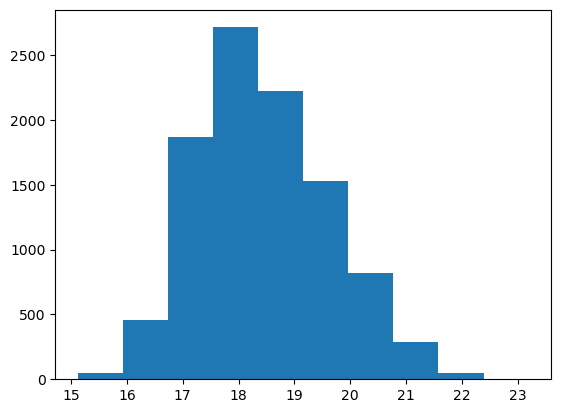

In [4]:
plt.hist(obsdata[2,:,0])


In [3]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000

x = [0.1,4.8,0.8,0.05,0.01,0.05]
prob_test = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, p_theta, smallest_N))

OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).


# Determine best number of Nsamps such that event % Nsamp is minimised

In [157]:
post_samps = []
for data_file in glob.glob(gw_path+'/*.hdf5'):
    f = h5py.File(data_file)
    post_samps.append(f['combined']['block0_values'].shape[0])
print(np.max(post_samps))
print(np.min(post_samps))

Nsamp=11058
Nsamp_below=np.array(post_samps)[np.array(post_samps)<Nsamp]

133905
1993


In [174]:
max_fraction =0.5

for Nsamp in np.linspace(8000,18000, 10000):
    Nsamp_below=np.array(post_samps)[np.array(post_samps)<int(Nsamp)]
    i=2
    Nsamp_below_new = np.copy(Nsamp_below)

    while np.any(Nsamp_below*i < Nsamp):
        Nsamp_below_new[Nsamp_below*i < Nsamp] = Nsamp_below[Nsamp_below*i < Nsamp]*i
        i+=1
    
    if np.all(-((Nsamp_below_new-Nsamp)/Nsamp_below)%0.5<max_fraction):
        max_fraction= np.max(-((Nsamp_below_new-Nsamp)/Nsamp_below)%0.5)
        best_Nsamp = Nsamp

In [175]:
best_Nsamp

11058.305830583058

## Likelihood across chi_b with different seeds

In [ ]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000


prob = np.zeros((20,5))
for seed in range(5):
    np.random.seed(seed)
    observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            10000, 'posteriors', 'p_theta_jcb')
    #for e, event in enumerate(obsdata):
    for i, chib in enumerate(tqdm(np.linspace(0,0.1,20))):
        x = [chib,4.8,0.8,0.05,0.01,0.05]
        prob[i,seed] = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, None, smallest_N))

In [ ]:
for seed in range(5):
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])))
plt.xlabel('chi_b')
plt.ylabel('normalised p(chi_b)')

In [ ]:
#across channels

prob = np.zeros((10,20))
for chnl in channels:
    for seed in range(5):
        np.random.seed(12)
        observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                                100, 'posteriors', 'p_theta_jcb')

        np.random.seed(seed)
        obsdata +=0.1*(np.random.rand(np.shape(obsdata[:,:,:])[0],np.shape(obsdata[:,:,:])[1],np.shape(obsdata[:,:,:])[2],)-0.5)
        #plt.hist(obsdata[0,:,2], bins=20, alpha=0.5)
        obsdata[obsdata[:,:,2]>0.99] = 0.99
        obsdata[obsdata[:,:,1]>0.99] = 0.99
        obsdata[obsdata[:,:,1]<0.001] = 0.001
        obsdata[obsdata[:,:,3]<0.001] = 0.001
        for i, chib in enumerate(np.linspace(0,0.1,20)):
            x = [chib,4.8,0.8,0.05,0.01,0.05]
            prob[seed,i] = (lnlike_cont(x, obsdata, flow, submodels_dict, [chnl], None, smallest_N))
        plt.plot(np.linspace(0,0.1,20), np.exp(prob[seed,:])/np.sum(np.exp(prob[seed,:])))
    plt.xlabel('chi_b')
    plt.ylabel('normalised p(chi_b)')
    plt.title(chnl)
    plt.show()

# and alpha_CE

In [11]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000


prob = np.zeros((20,2))
seed=1

for fidx, flow in enumerate([flow_mixed, prod_flow]):
    np.random.seed(seed)
    observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            1000, 'posteriors', 'p_theta_jcb')
    #for e, event in enumerate(obsdata):
    for i, alpha in enumerate(tqdm(np.linspace(3.,5.,20))):
        x = [0.03,alpha,0.87,0.05,0.01,0.05]
        prob[i,fidx] = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, p_theta, smallest_N))

100%|██████████| 20/20 [00:28<00:00,  1.42s/it]


In [14]:
prob.shape

(20, 2)

0
1


Text(0, 0.5, 'p(alpha_CE)')

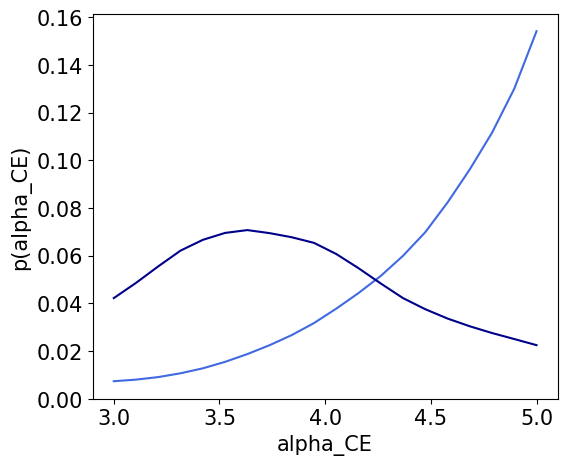

In [15]:
plt.rcParams["figure.figsize"] = (6,5)
for seed in range(2):
    print(seed)
    plt.plot(np.linspace(3.,5.,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])), color=color[seed])
plt.xlabel('alpha_CE')
plt.ylabel('p(alpha_CE)')

Text(0, 0.5, 'normalised p(alpha_CE)')

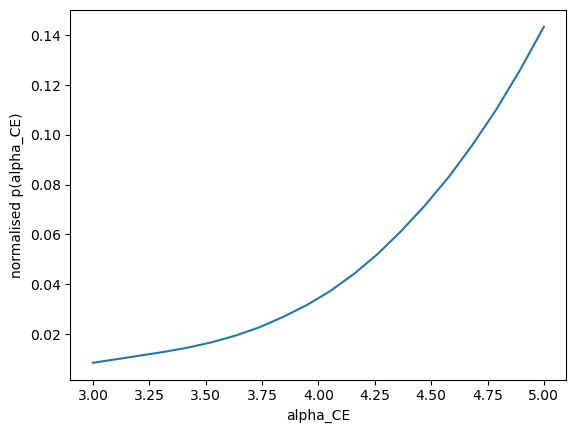

In [20]:
for seed in range(1):
    plt.plot(np.linspace(3.,5.,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])))
plt.xlabel('alpha_CE')
plt.ylabel('normalised p(alpha_CE)')

Text(0, 0.5, 'normalised p(alpha_CE)')

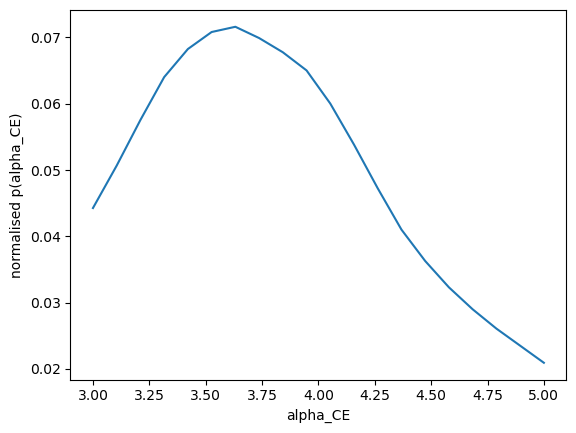

In [14]:
for seed in range(1):
    plt.plot(np.linspace(3.,5.,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])))
plt.xlabel('alpha_CE')
plt.ylabel('normalised p(alpha_CE)')

# comparing flows

In [2]:
params = ['mchirp','q', 'chieff', 'z']

file_path='/data/wiay/2297403c/models_reduced.hdf5'
gw_path = "/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/GWTC-3/events"
channels =['CE', 'CHE', 'GC', 'NSC', 'SMT']

mixed_path = "/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/mixed_models/"
prod_path = "/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/prod/"

model_names, flow_mixed = read_models.get_models(file_path, channels, params, use_flows=True, device='cpu',\
     no_bins=[5,4,4,5,4], sensitivity='midhighlatelow_network', flow_path=mixed_path)
for chnl in channels: flow_mixed[chnl].load_model(mixed_path, device='cpu')


_, prod_flow = read_models.get_models(file_path, channels, params, use_flows=True, device='cpu',\
     no_bins=[5,4,4,5,4], sensitivity='midhighlatelow_network', flow_path=prod_path)
for chnl in channels: prod_flow[chnl].load_model(prod_path, device='cpu')


100%|██████████| 5/5 [01:49<00:00, 21.86s/it]


In [3]:
popsynth_outputs = read_hdf5(file_path, 'CE') # read all data from hdf5 file

models_dict = dict.fromkeys(popsynth_outputs.keys())
weights_dict = dict.fromkeys(popsynth_outputs.keys())


for key in popsynth_outputs.keys():
    models_dict[key] = popsynth_outputs[key][params]
    weights_dict[key]= popsynth_outputs[key]['weight']

OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).


tensor([[0.0000, 1.0986],
        [0.0000, 1.0986],
        [0.0000, 1.0986],
        ...,
        [0.0000, 1.0986],
        [0.0000, 1.0986],
        [0.0000, 1.0986]])
tensor([[0.0000, 1.0986],
        [0.0000, 1.0986],
        [0.0000, 1.0986],
        ...,
        [0.0000, 1.0986],
        [0.0000, 1.0986],
        [0.0000, 1.0986]])


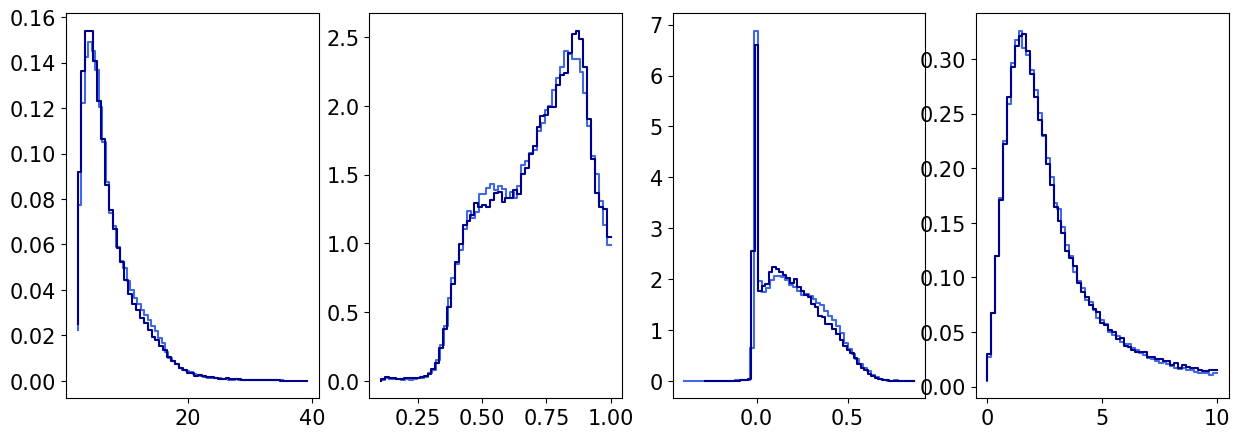

In [4]:
plt.rcParams["figure.figsize"] = (15,5)
plt.rcParams.update({'font.size': 15})
no_samples = 100000
no_bins = 60
chi_b=[0.,0.1,0.2,0.5]
alpha_CE = [0.2,0.5,1.0,2.,5.]
color=['royalblue', 'darkblue']


fig_mchirp, ax_m = plt.subplots(1,4)

param_label = ['$\mathcal{M}$ /$M_{\odot}$','q', '$\chi_{eff}$', 'z']

for fidx, flow in enumerate([flow_mixed['CE'], prod_flow['CE']]):
    for chi_b_id, xb in enumerate([0.]):
        for alpha_id, a in enumerate([3]):
            flow_samples_stack = flow.flow.sample(np.array([xb,np.log(a)]), no_samples)
            flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
            flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
            flow_chieff = np.tanh(flow_samples_stack[:,2])
            flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

            mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]


            for i, ax in enumerate(ax_m):
                flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
                ax.step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow', color=color[fidx])
                #ax[chi_b_id,alpha_id].legend()

tensor([[0.0000, 1.2528],
        [0.0000, 1.2528],
        [0.0000, 1.2528],
        ...,
        [0.0000, 1.2528],
        [0.0000, 1.2528],
        [0.0000, 1.2528]])
tensor([[0.0000, 1.2528],
        [0.0000, 1.2528],
        [0.0000, 1.2528],
        ...,
        [0.0000, 1.2528],
        [0.0000, 1.2528],
        [0.0000, 1.2528]])


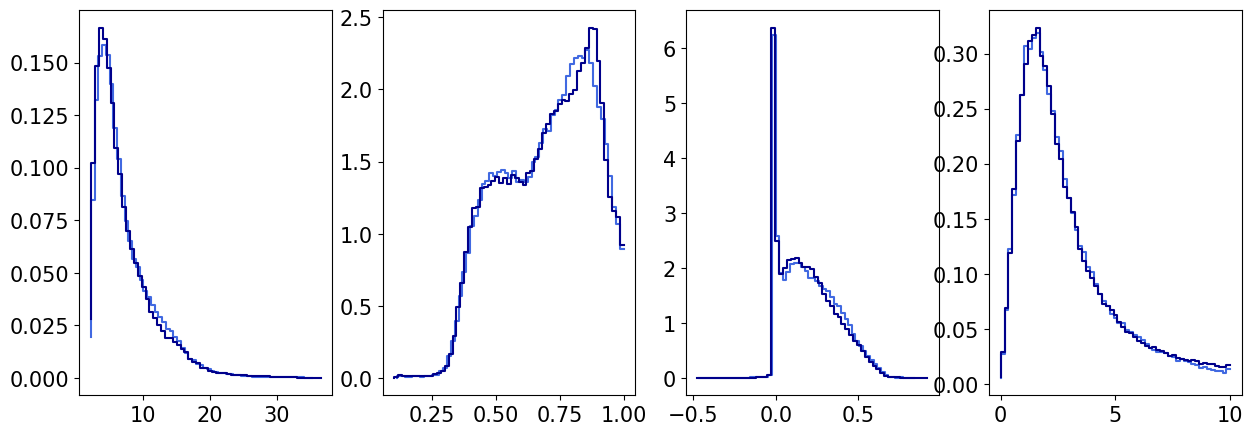

In [5]:
fig_mchirp, ax_m = plt.subplots(1,4)

for fidx, flow in enumerate([flow_mixed['CE'], prod_flow['CE']]):
    for chi_b_id, xb in enumerate([0.]):
        for alpha_id, a in enumerate([3.5]):
            flow_samples_stack = flow.flow.sample(np.array([xb,np.log(a)]), no_samples)
            flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
            flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
            flow_chieff = np.tanh(flow_samples_stack[:,2])
            flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

            mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]


            for i, ax in enumerate(ax_m):
                flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
                ax.step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow', color=color[fidx])
                #ax[chi_b_id,alpha_id].legend()
plt.show()

tensor([[0.0000, 1.5041],
        [0.0000, 1.5041],
        [0.0000, 1.5041],
        ...,
        [0.0000, 1.5041],
        [0.0000, 1.5041],
        [0.0000, 1.5041]])
tensor([[0.0000, 1.5041],
        [0.0000, 1.5041],
        [0.0000, 1.5041],
        ...,
        [0.0000, 1.5041],
        [0.0000, 1.5041],
        [0.0000, 1.5041]])


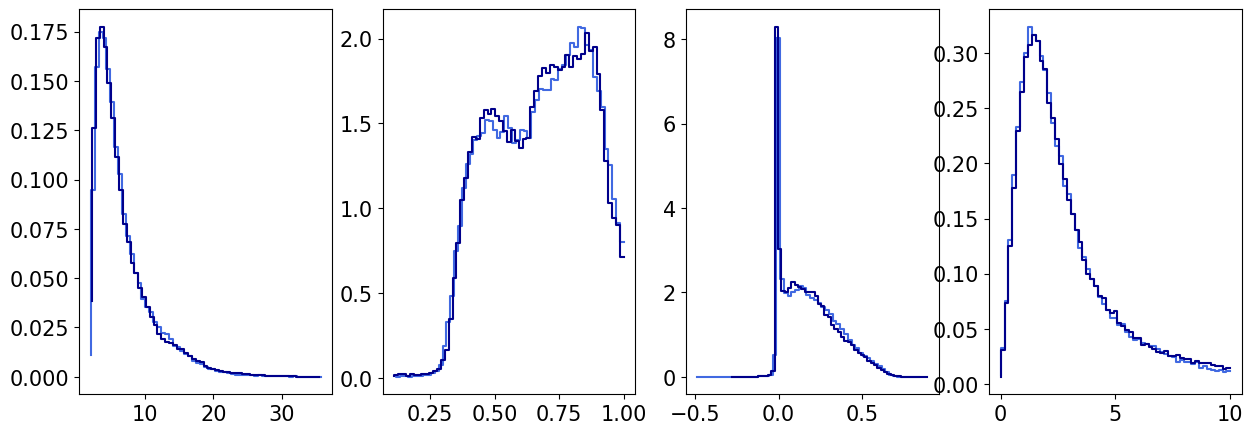

In [6]:
fig_mchirp, ax_m = plt.subplots(1,4)

for fidx, flow in enumerate([flow_mixed['CE'], prod_flow['CE']]):
    for chi_b_id, xb in enumerate([0.]):
        for alpha_id, a in enumerate([4.5]):
            flow_samples_stack = flow.flow.sample(np.array([xb,np.log(a)]), no_samples)
            flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
            flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
            flow_chieff = np.tanh(flow_samples_stack[:,2])
            flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

            mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]


            for i, ax in enumerate(ax_m):
                flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
                ax.step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow', color=color[fidx])
                #ax[chi_b_id,alpha_id].legend()
plt.show()

tensor([[0.0000, 1.6094],
        [0.0000, 1.6094],
        [0.0000, 1.6094],
        ...,
        [0.0000, 1.6094],
        [0.0000, 1.6094],
        [0.0000, 1.6094]])
tensor([[0.0000, 1.6094],
        [0.0000, 1.6094],
        [0.0000, 1.6094],
        ...,
        [0.0000, 1.6094],
        [0.0000, 1.6094],
        [0.0000, 1.6094]])


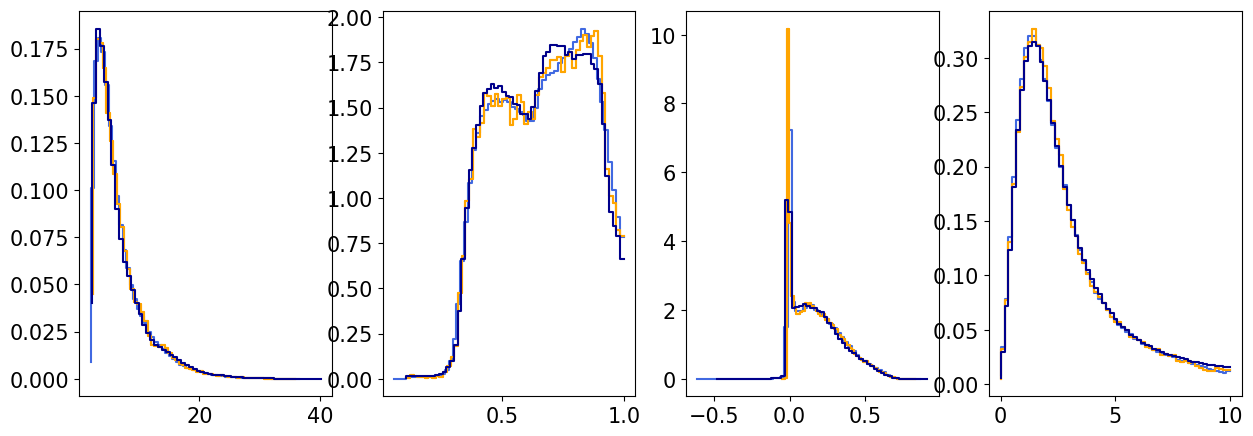

In [10]:
plt.rcParams["figure.figsize"] = (15,5)
plt.rcParams.update({'font.size': 15})
no_samples = 1000000
no_bins = 60
chi_b=[0.,0.1,0.2,0.5]
alpha_CE = [0.2,0.5,1.0,2.,5.]
color=['royalblue', 'darkblue']


fig_mchirp, ax_m = plt.subplots(1,4)

param_label = ['$\mathcal{M}$ /$M_{\odot}$','q', '$\chi_{eff}$', 'z']

for fidx, flow in enumerate([flow_mixed['CE'], prod_flow['CE']]):
    for chi_b_id, xb in enumerate([0.]):
        for alpha_id, a in enumerate([5]):
            flow_samples_stack = flow.flow.sample(np.array([xb,np.log(a)]), no_samples)
            flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
            flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
            flow_chieff = np.tanh(flow_samples_stack[:,2])
            flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

            mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]


            for i, ax in enumerate(ax_m):
                known_distr, bin_edges_known =np.histogram(models_dict[(0,4)][:][params[i]], bins=no_bins, density=True, weights=weights_dict[(0,4)])
                ax.step(np.linspace(bin_edges_known[0],bin_edges_known[-1],no_bins),known_distr, label='underlying', color='orange')
            
                flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
                ax.step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow', color=color[fidx])
                #ax[chi_b_id,alpha_id].legend()
plt.show()

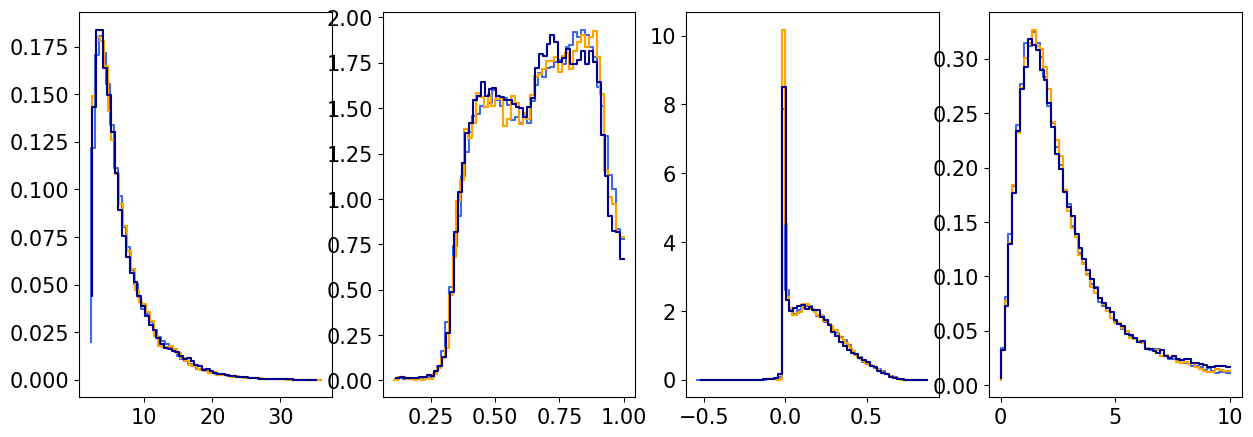

In [12]:
plt.rcParams["figure.figsize"] = (15,5)
plt.rcParams.update({'font.size': 15})
no_samples = 100000
no_bins = 60
chi_b=[0.,0.1,0.2,0.5]
alpha_CE = [0.2,0.5,1.0,2.,5.]
color=['royalblue', 'darkblue']


fig_mchirp, ax_m = plt.subplots(1,4)

param_label = ['$\mathcal{M}$ /$M_{\odot}$','q', '$\chi_{eff}$', 'z']

for fidx, flow in enumerate([flow_mixed['CE'], prod_flow['CE']]):
    for chi_b_id, xb in enumerate([0.]):
        for alpha_id, a in enumerate([5]):
            flow_samples_stack = flow.flow.sample(np.array([xb,np.log(a)]), no_samples)
            flow_mchirp = flow.expistic(flow_samples_stack[:,0], flow.mappings[0], flow.mappings[1])
            flow_q = flow.expistic(flow_samples_stack[:,1], flow.mappings[2])
            flow_chieff = np.tanh(flow_samples_stack[:,2])
            flow_z = flow.expistic(flow_samples_stack[:,3], flow.mappings[4], flow.mappings[5])

            mapped_flow_samples = [flow_mchirp,flow_q,flow_chieff,flow_z]


            for i, ax in enumerate(ax_m):
                known_distr, bin_edges_known =np.histogram(models_dict[(0,4)][:][params[i]], bins=no_bins, density=True, weights=weights_dict[(0,4)])
                ax.step(np.linspace(bin_edges_known[0],bin_edges_known[-1],no_bins),known_distr, label='underlying', color='orange')
            
                flow_distr, bin_edges = np.histogram(mapped_flow_samples[i], bins=no_bins, density=True)
                ax.step(np.linspace(bin_edges[0],bin_edges[-1],no_bins),flow_distr, label='flow', color=color[fidx])
                #ax[chi_b_id,alpha_id].legend()
plt.show()